# Nhóm 2, Notebook_A (Sinh viên A): dữ liệu, EDA, làm sạch, SQL, hình RQ1

**Đề tài:** Dự báo dư chấn ngắn hạn cho vùng Nhật Bản – Kuril, dùng hai nguồn dữ liệu chính phủ Hoa Kỳ.

| | Nguồn 1 | Nguồn 2 |
|---|---|---|
| Cơ quan | **USGS** (U.S. Geological Survey, Bộ Nội vụ) | **NOAA/NCEI** (Bộ Thương mại) |
| Bộ dữ liệu | ANSS ComCat, qua FDSN Event Web Service | Global Significant Earthquake DB + Global Historical Tsunami DB |
| Link gốc | `earthquake.usgs.gov/fdsnws/event/1/` | `ngdc.noaa.gov/hazel/hazard-service/api/v1/` |
| Nội dung | tham số địa chấn của từng trận | hậu quả: chết người, thiệt hại, sóng thần, runup |

Cả hai đều tải trực tiếp từ trang cơ quan liên bang, không qua Kaggle hay bản đăng lại.

**Notebook_A làm Bước 0 đến Bước 3 và hình RQ1.** Bàn giao cho Notebook_B: `data/processed/mainshocks.parquet` + `data/processed/manifest.json`.

## Vừa làm vừa hỏi AI và ghi Audit Log: cách làm nhẹ nhàng, không rối

Mỗi lần hỏi AI mà câu trả lời **làm thay đổi bài** thì ghi một dòng vào `docs/AI_Audit_Log_A.md`:

| Ngày | Prompt đã hỏi | AI trả lời gì | Mình giữ / sửa / bỏ | Vì sao |
|---|---|---|---|---|

Ba nguyên tắc:
1. **Không dán số của AI vào bài.** Mọi số trong report phải chạy ra từ notebook này.
2. **Hỏi "tại sao", không hỏi "viết hộ".** Ví dụ tốt: *"vì sao phải decluster trước khi chia train/test?"*
3. **Cái gì AI nói mà mình chưa kiểm được thì ghi rõ là chưa kiểm**, đừng viết như đã xác nhận.

## Bước 0: môi trường và cấu trúc thư mục

Chạy ô dưới một lần. Nếu thiếu thư viện thì cài rồi chạy lại.

```
Project/
  data/raw_japan/        <- CSV tải từ USGS + NOAA (scripts/fetch_japan_quake_data.py)
  data/processed/        <- mainshocks.parquet + manifest.json (Notebook_A tạo)
  report/                <- table_*.csv và fig_*.png
  sql/queries.sql        <- Notebook_A tự ghi ra khi chạy
```

In [1]:
# Step 0: kiem tra moi truong va tao cau truc thu muc
import sys, json, hashlib, warnings, pathlib
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd, duckdb
import matplotlib, matplotlib.pyplot as plt
from scipy import stats

print("python  ", sys.version.split()[0])
for m in (np, pd, duckdb, matplotlib):
    print(f"{m.__name__:<12}", m.__version__)

ROOT = pathlib.Path(".")
RAW  = ROOT / "data" / "raw_japan"
PROC = ROOT / "data" / "processed"
REP  = ROOT / "report"
SQLD = ROOT / "sql"
for d in (PROC, REP, SQLD):
    d.mkdir(parents=True, exist_ok=True)

need = ["usgs_japan_1990_2026.csv", "ncei_earthquakes.csv",
        "ncei_tsunami_events.csv", "ncei_tsunami_runups.csv"]
missing = [f for f in need if not (RAW / f).exists()]
assert not missing, f"Thieu file trong {RAW}: {missing}\n-> chay: python scripts/fetch_japan_quake_data.py"
print("\nDu lieu day du:")
for f in need:
    print(f"  {f:<34} {(RAW/f).stat().st_size/1e6:>7.2f} MB")

python   3.12.10
numpy        2.5.3
pandas       3.0.6
duckdb       1.5.5
matplotlib   3.11.2

Du lieu day du:
  usgs_japan_1990_2026.csv              7.27 MB
  ncei_earthquakes.csv                  0.06 MB
  ncei_tsunami_events.csv               0.05 MB
  ncei_tsunami_runups.csv               2.35 MB


In [2]:
# Bang mau chuan cho moi hinh trong bai (da validate CVD: xem docs)
PAL = {"s1": "#2a78d6", "s2": "#eb6834", "s3": "#1baf7a",
       "ink": "#0b0b0b", "ink2": "#52514e", "muted": "#898781",
       "grid": "#e1e0d9", "axis": "#c3c2b7", "surface": "#fcfcfb"}
SEQ5 = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]   # ramp mot mau, sang -> dam

plt.rcParams.update({
    "figure.facecolor": PAL["surface"], "axes.facecolor": PAL["surface"],
    "savefig.facecolor": PAL["surface"], "figure.dpi": 110, "savefig.dpi": 150,
    "savefig.bbox": "tight", "font.size": 10.5,
    "axes.edgecolor": PAL["axis"], "axes.labelcolor": PAL["ink2"],
    "axes.titlecolor": PAL["ink"], "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.titlepad": 11,
    "axes.grid": True, "grid.color": PAL["grid"], "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": PAL["muted"], "ytick.color": PAL["muted"],
    "xtick.labelcolor": PAL["ink2"], "ytick.labelcolor": PAL["ink2"],
    "lines.linewidth": 2.0, "lines.markersize": 8,
    "legend.frameon": False,
})

def finish(ax, title, sub=None, xlab=None, ylab=None):
    "Dat tieu de + tieu de phu KHONG chong nhau, nhan truc, day grid ra sau mark."
    ax.set_title("")
    if sub:
        ax.text(0, 1.012, sub, transform=ax.transAxes, fontsize=9.5,
                color=PAL["muted"], va="bottom")
        ax.text(0, 1.088, title, transform=ax.transAxes, fontsize=12.5,
                color=PAL["ink"], fontweight="semibold", va="bottom")
    else:
        ax.text(0, 1.012, title, transform=ax.transAxes, fontsize=12.5,
                color=PAL["ink"], fontweight="semibold", va="bottom")
    if xlab: ax.set_xlabel(xlab)
    if ylab: ax.set_ylabel(ylab)
    ax.set_axisbelow(True)
    return ax

def save(fig, name):
    p = REP / name
    fig.savefig(p)
    print("luu hinh:", p)

print("da nap bang mau va style chung")

da nap bang mau va style chung


## Bước 1: hiểu bài toán và nạp dữ liệu

### 1.1. Bài toán và bốn câu hỏi nghiên cứu

Khi một trận động đất vừa xảy ra, câu hỏi thực tế đầu tiên là: **sắp tới có dư chấn nữa không?** Đây là bài toán dự báo có thật, các cơ quan địa chấn đều phát hành sản phẩm này.

Định nghĩa bài toán trong project:

- **Đơn vị phân tích:** một **chuỗi** (sequence), tức một trận chính (mainshock) sau khi đã tách cụm (decluster).
- **Nhãn:** trong **24 giờ** sau trận chính, trong bán kính **100 km**, có ít nhất một dư chấn `M ≥ Mc` hay không.
- **Đặc trưng:** chỉ dùng thông tin **biết được ở thời điểm trận chính** — magnitude, độ sâu, vị trí. Không dùng gì ở tương lai.

Bốn câu hỏi nghiên cứu:

| RQ | Nội dung | Notebook |
|---|---|---|
| **RQ1** | Động đất vùng Nhật–Kuril 1990–2026 phân bố thế nào theo không gian, độ sâu, thời gian, magnitude? Độ sâu có liên quan tới năng suất dư chấn không? | **A** |
| **RQ2** | Từ tham số trận chính, dự báo có dư chấn trong 24h có thắng được mốc naive và mốc vật lý không? | B |
| **RQ3** | Mô hình có tổng quát sang thời kỳ chưa thấy không? Đổi ngưỡng nhãn sang mức gây hại thì còn giữ được không? | C |
| **RQ4** | Chuỗi nào dẫn tới hậu quả thật (chết người, thiệt hại, sóng thần)? Ghép nguồn NOAA/NCEI. | D |

**Ranh giới nhãn là ranh giới thời gian.** Đặc trưng nằm ở thời điểm `t`, nhãn nằm trong `(t, t+24h]`. Nên không thể có chuyện nhãn trùng với đặc trưng — đây là điểm khác căn bản so với những bài mà nhãn được suy ra từ chính cột đầu vào.

In [3]:
# Step 1: nap hai nguon
usgs = pd.read_csv(RAW / "usgs_japan_1990_2026.csv", low_memory=False)
usgs["time"] = pd.to_datetime(usgs["time"], utc=True, errors="coerce", format="ISO8601")

ncei_eq   = pd.read_csv(RAW / "ncei_earthquakes.csv", low_memory=False)
ncei_tsu  = pd.read_csv(RAW / "ncei_tsunami_events.csv", low_memory=False)
ncei_run  = pd.read_csv(RAW / "ncei_tsunami_runups.csv", low_memory=False)

print("NGUON 1 - USGS ANSS ComCat")
print(f"  {len(usgs):>7,} dong x {usgs.shape[1]} cot")
print(f"  thoi gian : {usgs['time'].min():%Y-%m-%d} -> {usgs['time'].max():%Y-%m-%d}")
print(f"  magnitude : M{usgs['mag'].min():.1f} -> M{usgs['mag'].max():.1f}")
print(f"  do sau    : {usgs['depth'].min():.1f} -> {usgs['depth'].max():.1f} km")
print("\nNGUON 2 - NOAA/NCEI")
for nm, d in [("significant earthquakes", ncei_eq), ("tsunami events", ncei_tsu),
              ("tsunami runups", ncei_run)]:
    print(f"  {nm:<24} {len(d):>7,} dong x {d.shape[1]} cot")

print("\nHop bao da dung khi tai (ghi ro trong report):")
print("  vi do  24N - 46N,  kinh do 122E - 150E")
print("  -> hop nay phu Nhat Ban VA phan nam cua quan dao Kuril (Nga).")
print("     Vi vay trong bai goi la 'vung Nhat-Kuril', khong goi la 'Nhat Ban' cho dung.")

NGUON 1 - USGS ANSS ComCat
   40,931 dong x 22 cot
  thoi gian : 1990-01-01 -> 2026-09-25
  magnitude : M4.0 -> M9.1
  do sau    : 0.0 -> 686.4 km

NGUON 2 - NOAA/NCEI
  significant earthquakes      429 dong x 46 cot
  tsunami events               385 dong x 48 cot
  tsunami runups            12,939 dong x 52 cot

Hop bao da dung khi tai (ghi ro trong report):
  vi do  24N - 46N,  kinh do 122E - 150E
  -> hop nay phu Nhat Ban VA phan nam cua quan dao Kuril (Nga).
     Vi vay trong bai goi la 'vung Nhat-Kuril', khong goi la 'Nhat Ban' cho dung.


### 1.2. EDA phần 1: cấu trúc bảng và ý nghĩa từng cột

22 cột của USGS. Điều cần biết trước khi dùng: **không phải cột nào cũng dùng được**. Một số cột gần như chỉ có một giá trị (không mang thông tin), một số thiếu quá nửa, và một số **mã hoá cơ quan nào xử lý bản ghi** — loại này nguy hiểm vì nó tương quan với thời kỳ, mô hình sẽ học "bản ghi này thời nào" thay vì học địa chấn.

In [4]:
# EDA 1: cau truc va y nghia cot
MEANING = {
 "time":"thoi diem goc (UTC)", "latitude":"vi do tam chan","longitude":"kinh do tam chan",
 "depth":"do sau tam chan (km)","mag":"magnitude","magType":"loai thang magnitude (mww, mb, ...)",
 "nst":"so tram dung de dinh vi","gap":"khoang trong phuong vi lon nhat (do)",
 "dmin":"khoang cach tram gan nhat","rms":"sai so binh phuong trung binh cua pha",
 "net":"mang dong gop ban ghi","id":"ma su kien","updated":"lan cap nhat cuoi",
 "place":"mo ta vi tri","type":"loai su kien","horizontalError":"sai so ngang (km)",
 "depthError":"sai so do sau (km)","magError":"sai so magnitude","magNst":"so tram tinh magnitude",
 "status":"da review hay tu dong","locationSource":"co quan dinh vi","magSource":"co quan tinh magnitude",
}
info = pd.DataFrame({
    "y_nghia": [MEANING.get(c, "") for c in usgs.columns],
    "kieu":    [str(usgs[c].dtype) for c in usgs.columns],
    "so_gia_tri": [usgs[c].nunique(dropna=True) for c in usgs.columns],
    "pct_thieu": [round(usgs[c].isna().mean()*100, 2) for c in usgs.columns],
}, index=usgs.columns)
display(info)

print("\nThong ke cac cot so chinh:")
display(usgs[["mag","depth","latitude","longitude","rms"]].describe().round(3))

,y_nghia,kieu,so_gia_tri,pct_thieu
time,thoi diem goc (UTC),"datetime64[us, UTC]",40931,0.00
latitude,vi do tam chan,float64,27758,0.00
longitude,kinh do tam chan,float64,25504,0.00
depth,do sau tam chan (km),float64,11152,0.00
mag,magnitude,float64,45,0.00
magType,"loai thang magnitude (mww, mb, ...)",str,9,0.00
nst,so tram dung de dinh vi,float64,590,42.09
gap,khoang trong phuong vi lon nhat (do),float64,2085,24.25
dmin,khoang cach tram gan nhat,float64,4456,61.93
rms,sai so binh phuong trung binh cua pha,float64,174,1.05



Thong ke cac cot so chinh:


,mag,depth,latitude,longitude,rms
count,40931.000,40931.000,40931.000,40931.000,40502.000
mean,4.548,66.786,34.936,139.582,0.857
std,0.414,98.657,5.996,6.400,0.249
min,4.000,0.000,24.000,122.000,0.100
25%,4.300,17.800,29.686,138.808,0.690
50%,4.500,35.000,36.007,141.650,0.840
75%,4.700,59.630,39.384,143.128,1.010
max,9.100,686.390,45.999,149.999,1.940


### 1.3. EDA phần 2: audit cột — cột nào phải loại và vì sao

Quy tắc loại, quyết định **trước** khi xem mô hình chạy ra sao (để không phải chọn cột theo kết quả):

1. **≥ 99% một giá trị** → loại, không mang thông tin.
2. **Thiếu ≥ 50%** → loại khỏi feature, chỉ dùng để mô tả.
3. **Mã hoá cơ quan / chất lượng đo** (`net`, `locationSource`, `magSource`, `*Error`, `nst`, `gap`, `magNst`, `status`) → **loại dù có đầy đủ**. Lý do: chất lượng mạng quan trắc cải thiện dần theo thập kỷ, nên các cột này là **dấu vân tay thời gian**. Khi ta chia train/test theo thời gian, mô hình có thể dùng chúng để đoán "đây là dữ liệu thời nào" — đó là học vào quy trình đo, không phải học vào địa chấn.

In [5]:
# EDA 2: audit cot -> report/table_col_audit.csv
FINGERPRINT = {"net","locationSource","magSource","horizontalError","depthError",
               "magError","nst","gap","magNst","status","dmin","rms","updated","id","place","type"}
rows = []
for c in usgs.columns:
    nn = usgs[c].notna().sum()
    dom = usgs[c].value_counts(dropna=True).iloc[0] / nn * 100 if nn else 0.0
    miss = usgs[c].isna().mean() * 100
    reasons = []
    if nn == 0:                 reasons.append("rong hoan toan")
    if dom >= 99:               reasons.append(f"{dom:.1f}% mot gia tri")
    if miss >= 50:              reasons.append(f"thieu {miss:.0f}%")
    if c in FINGERPRINT:        reasons.append("dau van tay co quan/thoi ky")
    rows.append({"cot": c, "pct_gia_tri_pho_bien": round(dom,2), "pct_thieu": round(miss,2),
                 "quyet_dinh": "LOAI" if reasons else "GIU",
                 "ly_do": "; ".join(reasons) if reasons else "dung lam dac trung hoac nhan"})
audit = pd.DataFrame(rows)
audit.to_csv(REP / "table_col_audit.csv", index=False)
display(audit)

KEEP = audit.loc[audit["quyet_dinh"] == "GIU", "cot"].tolist()
print("\nCot giu lai:", KEEP)
print(f"-> giu {len(KEEP)}/{len(usgs.columns)} cot. Dac trung cho mo hinh se chi lay tu day.")

,cot,pct_gia_tri_pho_bien,pct_thieu,quyet_dinh,ly_do
0,time,0.00,0.00,GIU,dung lam dac trung hoac nhan
1,latitude,0.02,0.00,GIU,dung lam dac trung hoac nhan
2,longitude,0.03,0.00,GIU,dung lam dac trung hoac nhan
3,depth,18.38,0.00,GIU,dung lam dac trung hoac nhan
4,mag,13.11,0.00,GIU,dung lam dac trung hoac nhan
5,magType,84.80,0.00,GIU,dung lam dac trung hoac nhan
6,nst,2.14,42.09,LOAI,dau van tay co quan/thoi ky
7,gap,1.75,24.25,LOAI,dau van tay co quan/thoi ky
8,dmin,0.10,61.93,LOAI,thieu 62%; dau van tay co quan/thoi ky
9,rms,3.65,1.05,LOAI,dau van tay co quan/thoi ky



Cot giu lai: ['time', 'latitude', 'longitude', 'depth', 'mag', 'magType']
-> giu 6/22 cot. Dac trung cho mo hinh se chi lay tu day.


## Bước 2: làm sạch, chọn ngưỡng đầy đủ Mc, tách cụm dư chấn

Ba việc, theo thứ tự, mỗi việc có lý do riêng:

**2a. Làm sạch.** Bỏ dòng thiếu toạ độ / thời gian / magnitude, bỏ id trùng, sắp theo thời gian.

**2b. Chọn Mc (magnitude of completeness).** Catalog không đầy đủ ở magnitude nhỏ — những trận bé quá thì mạng quan trắc không ghi hết. Nếu để nguyên, "không có dư chấn" sẽ lẫn với "có mà không ai ghi". Ta ước lượng Mc bằng **maximum curvature + 0.2** (Woessner & Wiemer 2005) rồi chỉ dùng phần catalog từ Mc trở lên.

**2c. Tách cụm (declustering) bằng Gardner–Knopoff 1974.** Dư chấn không độc lập với trận chính. Nếu để chung rồi chia train/test ngẫu nhiên, dư chấn của cùng một chuỗi sẽ rơi vào cả hai bên → rò rỉ. Gardner–Knopoff định nghĩa cửa sổ không–thời gian quanh mỗi trận theo magnitude của nó:

$$d(M) = 10^{\,0.1238M + 0.983}\ \text{km}, \qquad
t(M) = \begin{cases} 10^{\,0.032M + 2.7389} & M \ge 6.5 \\ 10^{\,0.5409M - 0.547} & M < 6.5 \end{cases}\ \text{ngày}$$

Mọi trận nhỏ hơn nằm trong cửa sổ của một trận lớn hơn được gán là dư chấn của chuỗi đó.

In [6]:
# Step 2a: lam sach + nhat ky lam sach
log = []
def step(name, before, after, note=""):
    log.append({"buoc": name, "dong_truoc": before, "dong_sau": after,
                "da_bo": before - after, "ghi_chu": note})

h = usgs.copy(); n0 = len(h)
h = h.dropna(subset=["time"]);                      step("bo thieu thoi gian", n0, len(h)); n0 = len(h)
h = h.dropna(subset=["latitude","longitude"]);      step("bo thieu toa do", n0, len(h)); n0 = len(h)
h = h.dropna(subset=["mag"]);                       step("bo thieu magnitude", n0, len(h)); n0 = len(h)
h = h.dropna(subset=["depth"]);                     step("bo thieu do sau", n0, len(h)); n0 = len(h)
h = h.drop_duplicates(subset="id");                 step("bo id trung", n0, len(h)); n0 = len(h)
h = h[h["type"] == "earthquake"];                   step("chi giu type=earthquake", n0, len(h),
                                                         "bo no min, sut lo dat...")
h = h.sort_values("time").reset_index(drop=True)

clean_log = pd.DataFrame(log)
clean_log.to_csv(REP / "table_cleaning_log.csv", index=False)
display(clean_log)
print(f"Con lai {len(h):,} su kien sach.")

,buoc,dong_truoc,dong_sau,da_bo,ghi_chu
0,bo thieu thoi gian,40931,40931,0,
1,bo thieu toa do,40931,40931,0,
2,bo thieu magnitude,40931,40931,0,
3,bo thieu do sau,40931,40931,0,
4,bo id trung,40931,40931,0,
5,chi giu type=earthquake,40931,40924,7,"bo no min, sut lo dat..."


Con lai 40,924 su kien sach.


mode cua histogram magnitude : M 4.4
Mc = maximum curvature + 0.2 : M 4.6
he so b (Gutenberg-Richter, fit tu Mc) = 1.02   (gia tri quen thuoc ~0.8-1.2)


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


luu hinh: report\fig_rq1_gutenberg_richter.png


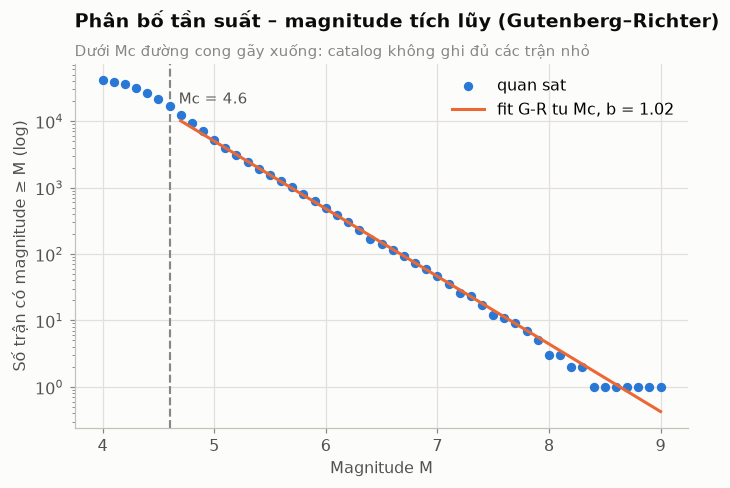


Catalog dung tu day: 16,687 su kien (M >= 4.6)


In [7]:
# Step 2b: uoc luong Mc bang maximum curvature + 0.2
bins = np.arange(np.floor(h["mag"].min()*10)/10, h["mag"].max()+0.1, 0.1)
cnt, edges = np.histogram(h["mag"], bins=bins)
mc_maxc = edges[int(np.argmax(cnt))]
Mc = round(float(mc_maxc) + 0.2, 1)
print(f"mode cua histogram magnitude : M {mc_maxc:.1f}")
print(f"Mc = maximum curvature + 0.2 : M {Mc:.1f}")

# Gutenberg-Richter: kiem tra duong tich luy co thang tu Mc tro len khong
mags = np.arange(4.0, h["mag"].max(), 0.1)
Ncum = np.array([(h["mag"] >= m).sum() for m in mags])
ok = (mags >= Mc) & (Ncum > 0)
b_gr, a_gr = np.polyfit(mags[ok], np.log10(Ncum[ok]), 1)
print(f"he so b (Gutenberg-Richter, fit tu Mc) = {-b_gr:.2f}   (gia tri quen thuoc ~0.8-1.2)")

fig, ax = plt.subplots(figsize=(7.2, 4.3))
ax.scatter(mags, Ncum, s=26, color=PAL["s1"], zorder=3, label="quan sat")
ax.plot(mags[ok], 10**(a_gr + b_gr*mags[ok]), color=PAL["s2"], lw=2,
        label=f"fit G-R tu Mc, b = {-b_gr:.2f}", zorder=4)
ax.axvline(Mc, color=PAL["muted"], ls="--", lw=1.4, zorder=2)
ax.annotate(f"Mc = {Mc}", xy=(Mc, Ncum.max()*0.45), xytext=(6, 0),
            textcoords="offset points", color=PAL["ink2"], fontsize=10)
ax.set_yscale("log")
finish(ax, "Phân bố tần suất – magnitude tích lũy (Gutenberg–Richter)",
       "Dưới Mc đường cong gãy xuống: catalog không ghi đủ các trận nhỏ",
       "Magnitude M", "Số trận có magnitude ≥ M (log)")
ax.legend(loc="upper right")
save(fig, "fig_rq1_gutenberg_richter.png"); plt.show()

cat = h[h["mag"] >= Mc].reset_index(drop=True)
print(f"\nCatalog dung tu day: {len(cat):,} su kien (M >= {Mc})")

In [8]:
# Step 2c: declustering Gardner-Knopoff 1974
R_EARTH = 6371.0
def haversine_km(lat1, lon1, lat2, lon2):
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = p2 - p1
    dlam = np.radians(lon2 - lon1)
    x = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlam/2)**2
    return 2 * R_EARTH * np.arcsin(np.sqrt(np.clip(x, 0, 1)))

def gk_window(m):
    "Gardner-Knopoff 1974: tra ve (ban kinh km, thoi gian ngay)."
    d = 10 ** (0.1238*m + 0.983)
    t = np.where(m >= 6.5, 10**(0.032*m + 2.7389), 10**(0.5409*m - 0.547))
    return d, t

t_s  = cat["time"].values.astype("datetime64[s]").astype(np.int64)
lat_, lon_, mag_ = cat["latitude"].values, cat["longitude"].values, cat["mag"].values
n = len(cat)
cluster_id = np.full(n, -1, dtype=np.int64)     # -1 = doc lap (mainshock)
cid = 0
for i in np.argsort(-mag_):                      # xet tu tran lon nhat xuong
    if cluster_id[i] != -1:
        continue
    d_km, t_day = gk_window(mag_[i])
    lo = np.searchsorted(t_s, t_s[i])
    hi = np.searchsorted(t_s, t_s[i] + int(t_day * 86400))
    if hi <= lo + 1:
        continue
    idx = np.arange(lo, hi)
    idx = idx[(cluster_id[idx] == -1) & (mag_[idx] < mag_[i]) & (idx != i)]
    if idx.size == 0:
        continue
    hit = idx[haversine_km(lat_[i], lon_[i], lat_[idx], lon_[idx]) <= d_km]
    if hit.size:
        cluster_id[hit] = cid
        cid += 1

cat["is_aftershock"] = cluster_id != -1
independent = cat[~cat["is_aftershock"]].reset_index(drop=True)

print(f"Gan la du chan     : {int(cat['is_aftershock'].sum()):>7,} ({cat['is_aftershock'].mean()*100:.1f}%)")
print(f"Su kien doc lap    : {len(independent):>7,}")
print(f"So cum tim duoc    : {cid:>7,}")
print("\n(Ty le 50-70% la khoang binh thuong cua Gardner-Knopoff; Notebook_C se kiem")
print(" do nhay bang mot phuong phap tach cum khac.)")
print("\nSo su kien doc lap theo nguong magnitude - day la so GROUP doc lap that:")
for m in (5.0, 5.5, 6.0, 6.5):
    print(f"  M >= {m}: {(independent['mag'] >= m).sum():>6,}")

Gan la du chan     :  10,401 (62.3%)
Su kien doc lap    :   6,286
So cum tim duoc    :   1,557

(Ty le 50-70% la khoang binh thuong cua Gardner-Knopoff; Notebook_C se kiem
 do nhay bang mot phuong phap tach cum khac.)

So su kien doc lap theo nguong magnitude - day la so GROUP doc lap that:
  M >= 5.0:  2,285
  M >= 5.5:    853
  M >= 6.0:    322
  M >= 6.5:    111


### 2.1. Bảng trận chính và nhãn — đây là bảng bàn giao cho Notebook_B

Chọn **M ≥ 5.5** làm ngưỡng trận chính. Lý do chọn mức này, không phải mức khác:

- **M ≥ 5.0** cho nhiều chuỗi hơn (2.289) nhưng chỉ 22% có dư chấn → lệch lớp nặng.
- **M ≥ 6.0** cân bằng đẹp nhất (49,5%) nhưng chỉ còn 323 chuỗi.
- **M ≥ 5.5** là điểm dung hoà: **854 chuỗi**, 34,4% dương.

Notebook_C sẽ chạy lại cả ba ngưỡng để kiểm độ nhạy, nên lựa chọn này không bị khoá cứng.

In [9]:
# Step 2d: bang tran chinh + nhan (nhan nam o TUONG LAI cua dac trung)
MS_MIN, WIN_H, WIN_KM = 5.5, 24, 100

def count_aftershocks(sub, min_mag=None, hours=WIN_H, km=WIN_KM):
    "Dem su kien trong (t, t+hours] va trong ban kinh km, magnitude nho hon tran chinh."
    lim = Mc if min_mag is None else min_mag
    out = np.zeros(len(sub), dtype=np.int64)
    for k in range(len(sub)):
        r = sub.iloc[k]
        t0 = np.datetime64(r["time"].to_datetime64(), "s").astype(np.int64)
        a = np.searchsorted(t_s, t0); b = np.searchsorted(t_s, t0 + hours*3600)
        if b <= a:
            continue
        idx = np.arange(a, b)
        d = haversine_km(r["latitude"], r["longitude"], lat_[idx], lon_[idx])
        out[k] = int(((d <= km) & (mag_[idx] < r["mag"]) & (mag_[idx] >= lim)).sum())
    return out

ms = independent[independent["mag"] >= MS_MIN].reset_index(drop=True).copy()
ms["n_after24h"] = count_aftershocks(ms)
ms["any_after"]  = (ms["n_after24h"] > 0).astype(int)
ms["year"]       = ms["time"].dt.year
ms["depth_bin"]  = pd.cut(ms["depth"], [0, 30, 70, 150, 300, 700],
                          labels=["0-30", "30-70", "70-150", "150-300", "300-700"])

print(f"Tran chinh M >= {MS_MIN} : {len(ms):,} chuoi")
print(f"Co >= 1 du chan trong {WIN_H}h / {WIN_KM}km : {ms['any_after'].sum():,} "
      f"({ms['any_after'].mean()*100:.1f}%)")
print(f"So du chan  - trung binh {ms['n_after24h'].mean():.2f} | "
      f"trung vi {ms['n_after24h'].median():.0f} | max {ms['n_after24h'].max()}")
print(f"\nMOC NAIVE (Notebook_B phai thang cai nay): doan luon lop pho bien")
print(f"  do chinh xac = {max(ms['any_after'].mean(), 1-ms['any_after'].mean())*100:.1f}%, AUC = 0.500")
display(ms[["time","mag","depth","latitude","longitude","place","n_after24h","any_after"]].head(8))

Tran chinh M >= 5.5 : 853 chuoi
Co >= 1 du chan trong 24h / 100km : 294 (34.5%)
So du chan  - trung binh 4.32 | trung vi 0 | max 160

MOC NAIVE (Notebook_B phai thang cai nay): doan luon lop pho bien
  do chinh xac = 65.5%, AUC = 0.500


,time,mag,depth,latitude,longitude,place,n_after24h,any_after
0,1990-01-10 03:09:18.850000+00:00,5.7,33.7,39.646,143.288,"115 km E of Miyako, Japan",0,0
1,1990-01-10 03:11:17.630000+00:00,5.8,36.6,39.706,143.306,"117 km E of Miyako, Japan",0,0
2,1990-01-20 02:55:54.840000+00:00,5.7,47.5,40.097,142.314,"59 km NNE of Miyako, Japan",0,0
3,1990-01-30 03:15:02.200000+00:00,5.5,40.9,43.008,145.460,"36 km SSW of Nemuro, Japan",0,0
4,1990-02-11 17:46:06.170000+00:00,5.7,46.4,36.331,140.916,"29 km E of ?arai, Japan",0,0
5,1990-02-17 02:28:01.820000+00:00,6.1,65.9,29.533,130.732,"80 km SSE of Koshima, Japan",0,0
6,1990-02-20 06:53:39.890000+00:00,6.4,14.2,34.706,139.252,"28 km E of Shimoda, Japan",2,1
7,1990-03-11 22:46:34.680000+00:00,5.5,24.4,33.493,138.654,"129 km SSE of ?yama, Japan",0,0


### 2.2. Ghép nguồn thứ hai (NOAA/NCEI) — kiểm tra ghép được bao nhiêu

Hai nguồn không có khoá chung, vì là hai cơ quan độc lập. Ta ghép theo **thời gian ± 1 giờ và khoảng cách ≤ 150 km**. Nếu tỉ lệ ghép thấp thì RQ4 không làm được, nên phải kiểm ngay tại đây chứ không để đến Notebook_D mới biết.

In [10]:
# Step 2e: ghep USGS <-> NCEI, bao cao ty le khop
nc = ncei_eq[ncei_eq["year"] >= 1990].copy()
for c in ("month","day","hour","minute"):
    if c not in nc: nc[c] = 0
nc["ts"] = pd.to_datetime(dict(
    year=nc["year"],
    month=nc["month"].fillna(1).replace(0,1),
    day=nc["day"].fillna(1).replace(0,1),
    hour=nc["hour"].fillna(0), minute=nc["minute"].fillna(0)),
    errors="coerce", utc=True)
nc = nc.dropna(subset=["ts","latitude","longitude"]).reset_index(drop=True)

pairs = []
for _, r in nc.iterrows():
    t0 = np.datetime64(r["ts"].to_datetime64(), "s").astype(np.int64)
    a = np.searchsorted(t_s, t0 - 3600); b = np.searchsorted(t_s, t0 + 3600)
    if b <= a: continue
    idx = np.arange(a, b)
    d = haversine_km(r["latitude"], r["longitude"], lat_[idx], lon_[idx])
    j = int(np.argmin(d))
    if d[j] <= 150:
        pairs.append({"ncei_id": r["id"], "usgs_id": cat.iloc[idx[j]]["id"],
                      "d_km": round(float(d[j]), 1),
                      "d_giay": int(abs(t_s[idx[j]] - t0))})
link = pd.DataFrame(pairs)
link.to_csv(REP / "table_source_link.csv", index=False)

print(f"NCEI 1990+ dung duoc      : {len(nc)} su kien co hau qua duoc ghi nhan")
print(f"Ghep duoc voi USGS        : {len(link)}/{len(nc)} = {len(link)/len(nc)*100:.1f}%")
print(f"Lech thoi gian (trung vi) : {link['d_giay'].median():.0f} giay")
print(f"Lech khoang cach (trung vi): {link['d_km'].median():.1f} km")
print("\nCot hau qua CHI co o nguon 2, nguon 1 khong he co:")
for c in ("deaths","deathsTotal","injuries","damageMillionsDollars","housesDestroyed","tsunamiEventId"):
    if c in nc: print(f"  {c:<24} co gia tri o {nc[c].notna().sum():>3}/{len(nc)} su kien")
print("\n-> Bo nguon 2 di thi RQ4 khong con ton tai. Day la kiem chung 'nguon thu hai")
print("   co that su can thiet hay chi ghep cho du so nguon'.")

NCEI 1990+ dung duoc      : 111 su kien co hau qua duoc ghi nhan
Ghep duoc voi USGS        : 108/111 = 97.3%
Lech thoi gian (trung vi) : 28 giay
Lech khoang cach (trung vi): 0.0 km

Cot hau qua CHI co o nguon 2, nguon 1 khong he co:
  deaths                   co gia tri o  24/111 su kien
  deathsTotal              co gia tri o  25/111 su kien
  injuries                 co gia tri o  59/111 su kien
  damageMillionsDollars    co gia tri o  22/111 su kien
  housesDestroyed          co gia tri o  23/111 su kien
  tsunamiEventId           co gia tri o  72/111 su kien

-> Bo nguon 2 di thi RQ4 khong con ton tai. Day la kiem chung 'nguon thu hai
   co that su can thiet hay chi ghep cho du so nguon'.


## Bước 3: phân tích bằng SQL, trả lời RQ1 và tạo đặc trưng

Chín truy vấn DuckDB, mỗi truy vấn dùng một kỹ thuật khác nhau. Notebook tự ghi ra `sql/queries.sql`.

| # | Kỹ thuật | Trả lời gì |
|---|---|---|
| Q1 | `GROUP BY` + `CASE` | phân bố sự kiện theo tầng độ sâu (RQ1) |
| Q2 | hàm tổng hợp nhiều tầng | thống kê magnitude theo thập kỷ (RQ1) |
| Q3 | **window `RANGE` theo thời gian thật** | đếm sự kiện 24h trước mỗi trận → tạo đặc trưng |
| Q4 | kiểm tra chất lượng | id trùng, toạ độ lỗi, magnitude ngoài khoảng |
| Q5 | `INNER JOIN` hai nguồn | trận nào có hậu quả được NOAA ghi nhận (RQ4) |
| Q6 | `RANK() OVER (PARTITION BY)` | trận mạnh nhất mỗi thập kỷ |
| Q7 | `SELECT` + `ORDER BY` | 10 trận mạnh nhất toàn vùng |
| Q8 | truy vấn con trong `HAVING` | tầng độ sâu có năng suất dư chấn trên mức chung (RQ1) |
| Q9 | `LAG` + `LEAD` | khoảng cách thời gian giữa các trận liên tiếp |

**Q3 là trái tim của bài.** Cửa sổ `RANGE BETWEEN INTERVAL '24' HOURS PRECEDING` đếm theo **thời gian thật**, không phải theo số dòng — vì các trận không cách đều nhau, dùng `ROWS` sẽ sai.

In [11]:
# Step 3: chin truy van SQL trong DuckDB
con = duckdb.connect()
con.register("quakes", cat[["id","time","latitude","longitude","depth","mag","magType","place","is_aftershock"]])
con.register("mainshocks", ms[["id","time","latitude","longitude","depth","mag","n_after24h","any_after","year"]])
con.register("ncei", nc[["id","ts","latitude","longitude","eqMagnitude","deaths","deathsTotal",
                         "injuries","damageMillionsDollars","housesDestroyed","tsunamiEventId","locationName"]])
con.register("link", link)

QUERIES = {}

QUERIES["Q1_phan_bo_theo_tang_do_sau"] = '''
SELECT CASE WHEN depth <  30 THEN '1. 0-30 km (vo)'
            WHEN depth <  70 THEN '2. 30-70 km'
            WHEN depth < 150 THEN '3. 70-150 km'
            WHEN depth < 300 THEN '4. 150-300 km'
            ELSE                  '5. 300+ km (sau)' END      AS tang_do_sau,
       COUNT(*)                                               AS so_su_kien,
       ROUND(AVG(mag), 2)                                     AS mag_trung_binh,
       ROUND(MAX(mag), 1)                                     AS mag_lon_nhat,
       ROUND(100.0 * SUM(CASE WHEN is_aftershock THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_la_du_chan
FROM quakes
GROUP BY tang_do_sau
ORDER BY tang_do_sau
'''

QUERIES["Q2_thong_ke_theo_thap_ky"] = '''
SELECT CAST(FLOOR(YEAR(time) / 10) * 10 AS INTEGER)  AS thap_ky,
       COUNT(*)                                      AS so_su_kien,
       ROUND(AVG(mag), 2)                            AS mag_tb,
       ROUND(STDDEV_SAMP(mag), 2)                    AS mag_sd,
       ROUND(QUANTILE_CONT(mag, 0.5), 2)             AS mag_trung_vi,
       ROUND(AVG(depth), 1)                          AS do_sau_tb,
       COUNT(DISTINCT CAST(time AS DATE))            AS so_ngay_co_su_kien
FROM quakes
GROUP BY thap_ky
ORDER BY thap_ky
'''

QUERIES["Q3_dac_trung_cua_so_24h_RANGE"] = '''
SELECT id, time, mag, depth,
       COUNT(*)  OVER w24 - 1        AS so_tran_24h_truoc,
       ROUND(MAX(mag) OVER w24, 1)   AS mag_lon_nhat_24h_truoc,
       ROUND(AVG(mag) OVER w24, 2)   AS mag_tb_24h_truoc,
       COUNT(*)  OVER w7d - 1        AS so_tran_7ngay_truoc
FROM quakes
WINDOW w24 AS (ORDER BY time RANGE BETWEEN INTERVAL '24' HOURS PRECEDING AND CURRENT ROW),
       w7d AS (ORDER BY time RANGE BETWEEN INTERVAL  '7' DAYS  PRECEDING AND CURRENT ROW)
ORDER BY so_tran_24h_truoc DESC
LIMIT 20
'''

QUERIES["Q4_kiem_tra_chat_luong"] = '''
SELECT 'id bi trung'                AS phep_kiem, COUNT(*) AS so_dong_loi FROM (
         SELECT id FROM quakes GROUP BY id HAVING COUNT(*) > 1)
UNION ALL SELECT 'toa do ngoai hop bao', COUNT(*) FROM quakes
          WHERE latitude NOT BETWEEN 24 AND 46 OR longitude NOT BETWEEN 122 AND 150
UNION ALL SELECT 'do sau am',            COUNT(*) FROM quakes WHERE depth < 0
UNION ALL SELECT 'magnitude ngoai [Mc,10]', COUNT(*) FROM quakes WHERE mag < 4.0 OR mag > 10
UNION ALL SELECT 'thieu thoi gian',      COUNT(*) FROM quakes WHERE time IS NULL
'''

QUERIES["Q5_join_hai_nguon"] = '''
SELECT n.locationName                       AS dia_diem,
       CAST(n.ts AS DATE)                    AS ngay,
       q.mag                                 AS mag_usgs,
       ROUND(q.depth, 1)                     AS do_sau_usgs,
       n.deathsTotal                         AS so_chet,
       n.damageMillionsDollars               AS thiet_hai_trieu_usd,
       CASE WHEN n.tsunamiEventId IS NOT NULL THEN 'co' ELSE 'khong' END AS co_song_than,
       l.d_km                                AS lech_km,
       l.d_giay                              AS lech_giay
FROM link      l
INNER JOIN ncei   n ON n.id = l.ncei_id
INNER JOIN quakes q ON q.id = l.usgs_id
WHERE n.deathsTotal IS NOT NULL OR n.damageMillionsDollars IS NOT NULL
ORDER BY n.deathsTotal DESC NULLS LAST
LIMIT 15
'''

QUERIES["Q6_manh_nhat_moi_thap_ky"] = '''
SELECT thap_ky, place AS dia_diem, mag, ROUND(depth,1) AS do_sau, CAST(time AS DATE) AS ngay, hang
FROM (SELECT CAST(FLOOR(YEAR(time)/10)*10 AS INTEGER) AS thap_ky, place, mag, depth, time,
             RANK() OVER (PARTITION BY FLOOR(YEAR(time)/10) ORDER BY mag DESC) AS hang
      FROM quakes)
WHERE hang <= 3
ORDER BY thap_ky, hang
'''

QUERIES["Q7_manh_nhat_toan_vung"] = '''
SELECT CAST(time AS DATE) AS ngay, place AS dia_diem, mag, ROUND(depth,1) AS do_sau_km, magType AS thang_do
FROM quakes
ORDER BY mag DESC
LIMIT 10
'''

QUERIES["Q8_tang_do_sau_tren_muc_chung"] = '''
SELECT CASE WHEN depth <  30 THEN '0-30 km'   WHEN depth <  70 THEN '30-70 km'
            WHEN depth < 150 THEN '70-150 km' WHEN depth < 300 THEN '150-300 km'
            ELSE '300+ km' END                       AS tang_do_sau,
       COUNT(*)                                      AS so_chuoi,
       ROUND(AVG(n_after24h), 2)                     AS du_chan_tb,
       ROUND(100.0 * AVG(any_after), 1)              AS pct_co_du_chan
FROM mainshocks
GROUP BY tang_do_sau
HAVING AVG(n_after24h) > (SELECT AVG(n_after24h) FROM mainshocks)
ORDER BY du_chan_tb DESC
'''

QUERIES["Q9_khoang_cach_giua_cac_tran"] = '''
SELECT CAST(time AS DATE) AS ngay, place AS dia_diem, mag,
       ROUND(DATE_DIFF('minute', tran_truoc, time) / 60.0, 2) AS gio_tu_tran_truoc,
       ROUND(DATE_DIFF('minute', time, tran_sau)  / 60.0, 2)  AS gio_den_tran_sau,
       mag_truoc AS mag_tran_truoc
FROM (SELECT time, place, mag,
             LAG(time)  OVER (ORDER BY time) AS tran_truoc,
             LEAD(time) OVER (ORDER BY time) AS tran_sau,
             LAG(mag)   OVER (ORDER BY time) AS mag_truoc
      FROM quakes WHERE mag >= 6.0)
WHERE tran_truoc IS NOT NULL AND tran_sau IS NOT NULL
ORDER BY gio_tu_tran_truoc
LIMIT 15
'''

for name, q in QUERIES.items():
    print("=" * 78); print(name); print("=" * 78)
    r = con.execute(q).df()
    display(r)
    r.to_csv(REP / f"table_sql_{name}.csv", index=False)

with open(SQLD / "queries.sql", "w", encoding="utf-8") as f:
    f.write("-- Nhom 2 - ADY202m - du bao du chan vung Nhat-Kuril\n")
    f.write("-- Nguon 1: USGS ANSS ComCat | Nguon 2: NOAA/NCEI\n")
    f.write("-- File nay do Notebook_A tu ghi ra khi chay.\n\n")
    for name, q in QUERIES.items():
        f.write(f"-- {'='*70}\n-- {name}\n-- {'='*70}\n{q.strip()};\n\n")
print("da ghi", SQLD / "queries.sql")

Q1_phan_bo_theo_tang_do_sau


,tang_do_sau,so_su_kien,mag_trung_binh,mag_lon_nhat,pct_la_du_chan
0,1. 0-30 km (vo),6321,4.93,9.1,69.5
1,2. 30-70 km,8067,4.90,7.9,66.0
2,3. 70-150 km,1370,4.87,7.6,36.9
3,4. 150-300 km,353,4.94,7.1,11.6
4,5. 300+ km (sau),576,5.09,7.8,24.3


Q2_thong_ke_theo_thap_ky


,thap_ky,so_su_kien,mag_tb,mag_sd,mag_trung_vi,do_sau_tb,so_ngay_co_su_kien
0,1990,3490,4.98,0.42,4.8,64.8,1856
1,2000,2935,4.97,0.44,4.8,67.7,1653
2,2010,7398,4.88,0.36,4.8,43.0,2394
3,2020,2864,4.90,0.37,4.8,46.9,1431


Q3_dac_trung_cua_so_24h_RANGE


...

Q8_tang_do_sau_tren_muc_chung


,tang_do_sau,so_chuoi,du_chan_tb,pct_co_du_chan
0,0-30 km,308,7.83,64.3


Q9_khoang_cach_giua_cac_tran


,ngay,dia_diem,mag,gio_tu_tran_truoc,gio_den_tran_sau,mag_tran_truoc
0,2011-03-11,"47 km E of ?arai, Japan",7.90,0.00,0.05,6.3
1,1993-01-15,"52 km NE of Otofuke, Japan",7.60,0.00,99.55,6.1
2,2004-09-05,"119 km ESE of Shing?, Japan",6.51,0.00,32.53,7.4
3,2011-03-11,"208 km E of Namie, Japan",6.40,0.02,0.05,6.3
4,2011-03-11,"61 km ESE of Namie, Japan",6.20,0.02,0.03,6.2
5,2011-03-11,"128 km SE of ?funato, Japan",6.20,0.02,0.03,6.5
6,2011-03-11,"134 km ESE of Kamaishi, Japan",6.70,0.02,0.07,6.4
7,2011-03-11,"108 km ESE of Kitaibaraki, Japan",6.40,0.02,0.02,6.3
8,2011-03-11,"49 km ESE of Kamaishi, Japan",6.30,0.02,0.02,6.1
9,2011-03-11,"126 km ESE of Ishinomaki, Japan",6.00,0.02,0.07,6.1


da ghi sql\queries.sql


### 3.2. Trả lời RQ1 bằng kiểm định, không chỉ bằng mắt

Q1 và Q8 gợi ra rằng độ sâu liên quan tới năng suất dư chấn. Nhưng "nhìn thấy khác nhau" chưa phải bằng chứng — phải kiểm định.

- **Chi-square** cho tỉ lệ có/không có dư chấn giữa nhóm nông và nhóm sâu.
- **Kruskal–Wallis** cho số dư chấn giữa các tầng độ sâu (dùng kiểm định phi tham số vì phân bố lệch đuôi rất nặng, không phải chuẩn).
- **Spearman** cho tương quan đơn điệu giữa magnitude và số dư chấn.

In [12]:
# Step 3.2: kiem dinh cho RQ1
res = []

shallow = ms.loc[ms["depth"] <  70, "any_after"]
deep    = ms.loc[ms["depth"] >= 70, "any_after"]
ct = np.array([[shallow.sum(), len(shallow)-shallow.sum()],
               [deep.sum(),    len(deep)-deep.sum()]])
chi2, p_chi, _, _ = stats.chi2_contingency(ct)
res.append({"phep_kiem":"Chi-square: nong (<70km) vs sau (>=70km), co/khong du chan",
            "thong_ke":round(chi2,2), "p_value":p_chi,
            "ket_luan":"khac biet co y nghia" if p_chi<0.05 else "chua du bang chung"})

groups = [g["n_after24h"].values for _, g in ms.groupby("depth_bin", observed=True) if len(g) >= 10]
H, p_kw = stats.kruskal(*groups)
res.append({"phep_kiem":"Kruskal-Wallis: so du chan giua cac tang do sau",
            "thong_ke":round(H,2), "p_value":p_kw,
            "ket_luan":"khac biet co y nghia" if p_kw<0.05 else "chua du bang chung"})

rho, p_sp = stats.spearmanr(ms["mag"], ms["n_after24h"])
res.append({"phep_kiem":"Spearman: magnitude vs so du chan",
            "thong_ke":round(rho,3), "p_value":p_sp,
            "ket_luan":"tuong quan duong" if (p_sp<0.05 and rho>0) else "chua du bang chung"})

rho2, p_sp2 = stats.spearmanr(ms["depth"], ms["n_after24h"])
res.append({"phep_kiem":"Spearman: do sau vs so du chan",
            "thong_ke":round(rho2,3), "p_value":p_sp2,
            "ket_luan":"tuong quan am" if (p_sp2<0.05 and rho2<0) else "chua du bang chung"})

rq1 = pd.DataFrame(res)
rq1.to_csv(REP / "table_rq1_tests.csv", index=False)
display(rq1)

prod = ms.groupby("depth_bin", observed=True).agg(
    so_chuoi=("any_after","size"), pct_co_du_chan=("any_after","mean"),
    du_chan_tb=("n_after24h","mean"), du_chan_trung_vi=("n_after24h","median"))
prod["pct_co_du_chan"] = (prod["pct_co_du_chan"]*100).round(1)
prod = prod.round(2)
prod.to_csv(REP / "table_rq1_productivity.csv")
print("\nNang suat du chan theo tang do sau (bang chinh tra loi RQ1):")
display(prod)

,phep_kiem,thong_ke,p_value,ket_luan
0,"Chi-square: nong (<70km) vs sau (>=70km), co/k...",112.220,3.199141e-26,khac biet co y nghia
1,Kruskal-Wallis: so du chan giua cac tang do sau,217.670,5.954115e-46,khac biet co y nghia
2,Spearman: magnitude vs so du chan,0.276,2.045174e-16,tuong quan duong
3,Spearman: do sau vs so du chan,-0.492,2.675753e-53,tuong quan am



Nang suat du chan theo tang do sau (bang chinh tra loi RQ1):


,so_chuoi,pct_co_du_chan,du_chan_tb,du_chan_trung_vi
depth_bin,,,,
0-30,317,63.1,7.65,1.0
30-70,313,26.5,4.00,0.0
70-150,78,5.1,0.06,0.0
150-300,39,2.6,0.03,0.0
300-700,106,5.7,0.06,0.0


## Bước 5 (phần A): bộ hình trả lời RQ1

Bốn hình, mỗi hình một việc:

1. **Năng suất dư chấn theo độ sâu** — kết quả chính của RQ1.
2. **Phân bố không gian** — bản đồ tán xạ tâm chấn, màu theo độ sâu.
3. **Chuỗi thời gian theo năm** — có thấy Tohoku 2011 không, và catalog có đều không.
4. **Magnitude vs số dư chấn** — quan hệ đơn điệu, thang log.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


luu hinh: report\fig_rq1_productivity_by_depth.png


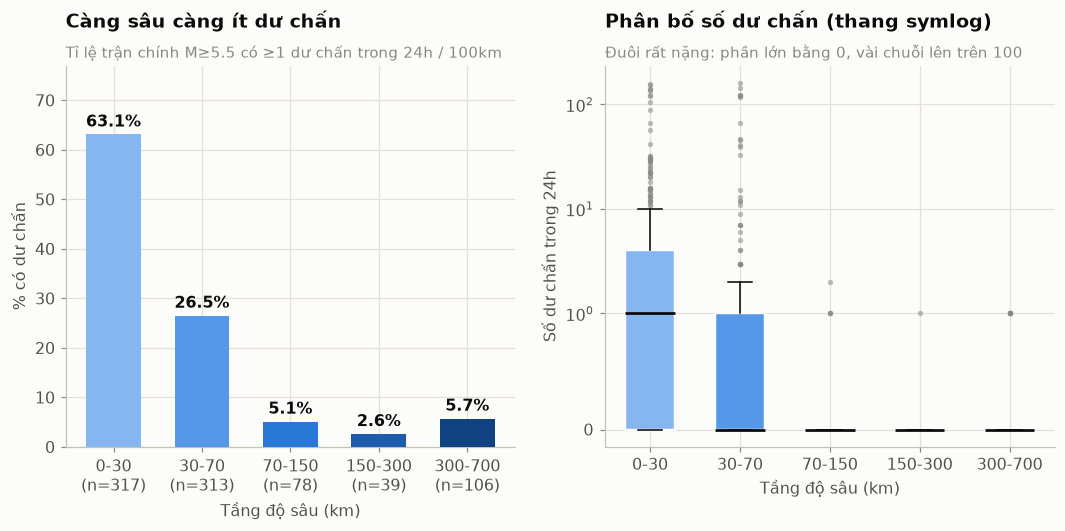

In [13]:
# Hinh 1: nang suat du chan theo tang do sau (ket qua chinh RQ1)
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.5))
labels = prod.index.astype(str).tolist()
colors = SEQ5[:len(labels)]

ax = axes[0]
tick_lab = [f"{l}\n(n={nn})" for l, nn in zip(labels, prod["so_chuoi"])]
bars = ax.bar(tick_lab, prod["pct_co_du_chan"], color=colors, width=0.62, zorder=3)
for bar, v in zip(bars, prod["pct_co_du_chan"]):
    ax.text(bar.get_x()+bar.get_width()/2, v+1.6, f"{v:.1f}%", ha="center",
            fontsize=10.5, color=PAL["ink"], fontweight="semibold")
finish(ax, "Càng sâu càng ít dư chấn",
       f"Tỉ lệ trận chính M≥{MS_MIN} có ≥1 dư chấn trong {WIN_H}h / {WIN_KM}km",
       "Tầng độ sâu (km)", "% có dư chấn")
ax.set_ylim(0, max(prod["pct_co_du_chan"])*1.22)

ax = axes[1]
data = [ms.loc[ms["depth_bin"]==b, "n_after24h"].values for b in prod.index]
bp = ax.boxplot(data, tick_labels=labels, patch_artist=True, widths=0.55,
                medianprops=dict(color=PAL["ink"], lw=1.8),
                flierprops=dict(marker="o", ms=3.5, mfc=PAL["muted"],
                                mec="none", alpha=0.55))
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c); patch.set_edgecolor("white"); patch.set_linewidth(1.6)
ax.set_yscale("symlog", linthresh=1)
finish(ax, "Phân bố số dư chấn (thang symlog)",
       "Đuôi rất nặng: phần lớn bằng 0, vài chuỗi lên trên 100",
       "Tầng độ sâu (km)", "Số dư chấn trong 24h")
save(fig, "fig_rq1_productivity_by_depth.png"); plt.show()

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


luu hinh: report\fig_rq1_map_epicenters.png


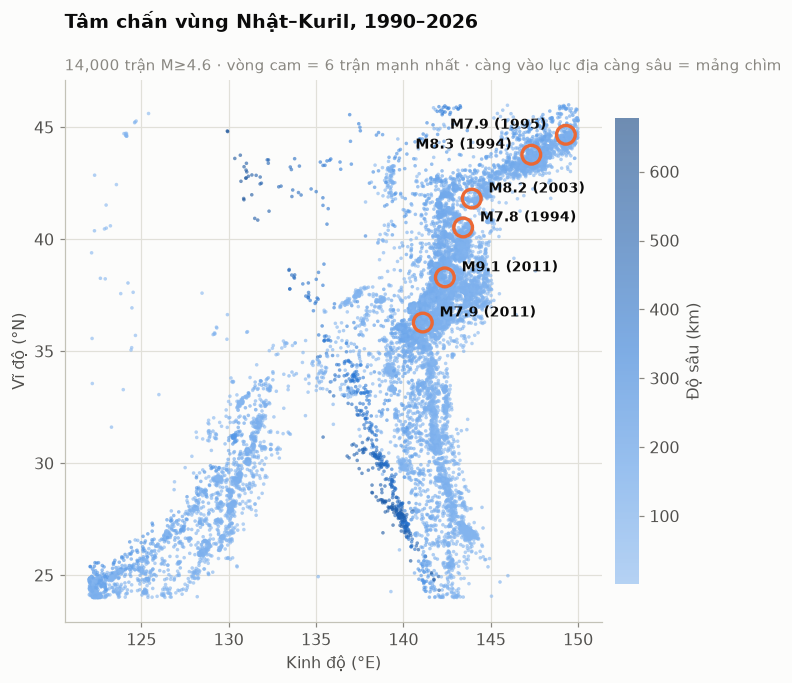

In [14]:
# Hinh 2: phan bo khong gian
fig, ax = plt.subplots(figsize=(7.6, 6.4))
d = cat.sample(min(len(cat), 14000), random_state=0)
sc = ax.scatter(d["longitude"], d["latitude"], c=d["depth"], s=5.5, alpha=0.6,
                cmap=matplotlib.colors.LinearSegmentedColormap.from_list("blues", SEQ5),
                linewidths=0, zorder=3)
big = cat.nlargest(6, "mag")
ax.scatter(big["longitude"], big["latitude"], s=150, facecolor="none",
           edgecolor=PAL["s2"], linewidth=2.2, zorder=5)
for _, r in big.iterrows():
    # diem sat mep phai -> dat nhan sang trai de khong de vao colorbar
    right_edge = r["longitude"] > 145.5
    ax.annotate(f"M{r['mag']:.1f} ({r['time']:%Y})", (r["longitude"], r["latitude"]),
                textcoords="offset points",
                xytext=(-13, 4) if right_edge else (11, 4),
                ha="right" if right_edge else "left",
                fontsize=9, color=PAL["ink"], fontweight="semibold", zorder=6)
cb = fig.colorbar(sc, ax=ax, pad=0.02, shrink=0.86)
cb.set_label("Độ sâu (km)", color=PAL["ink2"]); cb.outline.set_visible(False)
finish(ax, "Tâm chấn vùng Nhật–Kuril, 1990–2026",
       f"{len(d):,} trận M≥{Mc} · vòng cam = 6 trận mạnh nhất · càng vào lục địa càng sâu = mảng chìm",
       "Kinh độ (°E)", "Vĩ độ (°N)")
save(fig, "fig_rq1_map_epicenters.png"); plt.show()

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


luu hinh: report\fig_rq1_events_per_year.png


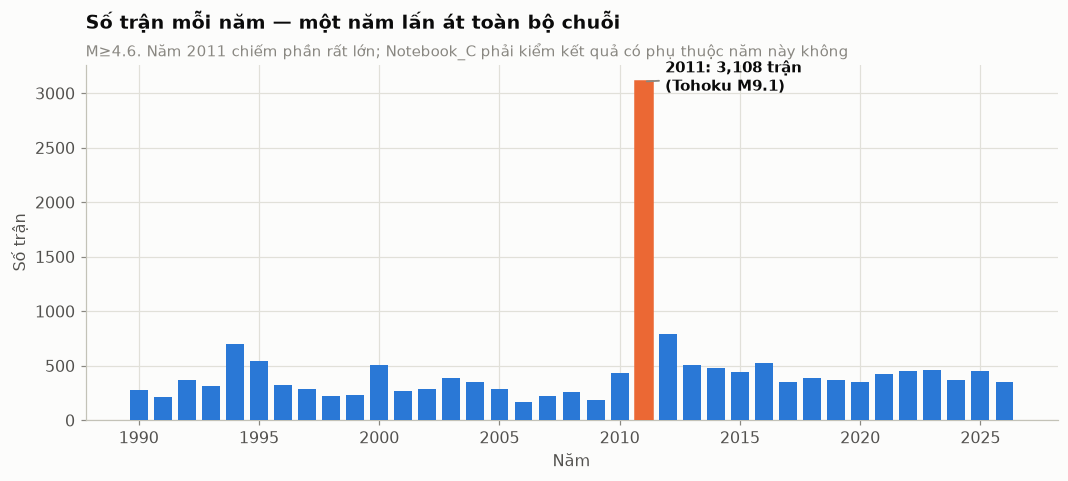

2011 chiem 18.6% tong su kien (3,108/16,687)


In [15]:
# Hinh 3: chuoi thoi gian theo nam
by_year = cat.groupby(cat["time"].dt.year).agg(
    so_su_kien=("id","size"), mag_lon_nhat=("mag","max")).reset_index(names="nam")
fig, ax = plt.subplots(figsize=(11.4, 4.2))
bars = ax.bar(by_year["nam"], by_year["so_su_kien"], color=PAL["s1"], width=0.74, zorder=3)
top = by_year.nlargest(1, "so_su_kien").iloc[0]
bars[list(by_year["nam"]).index(top["nam"])].set_color(PAL["s2"])
ax.annotate(f"{int(top['nam'])}: {int(top['so_su_kien']):,} trận\n(Tohoku M9.1)",
            xy=(top["nam"], top["so_su_kien"]), xytext=(14, -6),
            textcoords="offset points", fontsize=10, color=PAL["ink"],
            fontweight="semibold",
            arrowprops=dict(arrowstyle="-", color=PAL["muted"], lw=1.2))
finish(ax, "Số trận mỗi năm — một năm lấn át toàn bộ chuỗi",
       f"M≥{Mc}. Năm 2011 chiếm phần rất lớn; Notebook_C phải kiểm kết quả có phụ thuộc năm này không",
       "Năm", "Số trận")
save(fig, "fig_rq1_events_per_year.png"); plt.show()
print(f"2011 chiem {top['so_su_kien']/by_year['so_su_kien'].sum()*100:.1f}% tong su kien "
      f"({int(top['so_su_kien']):,}/{by_year['so_su_kien'].sum():,})")

luu hinh: report\fig_rq1_magnitude_vs_aftershocks.png


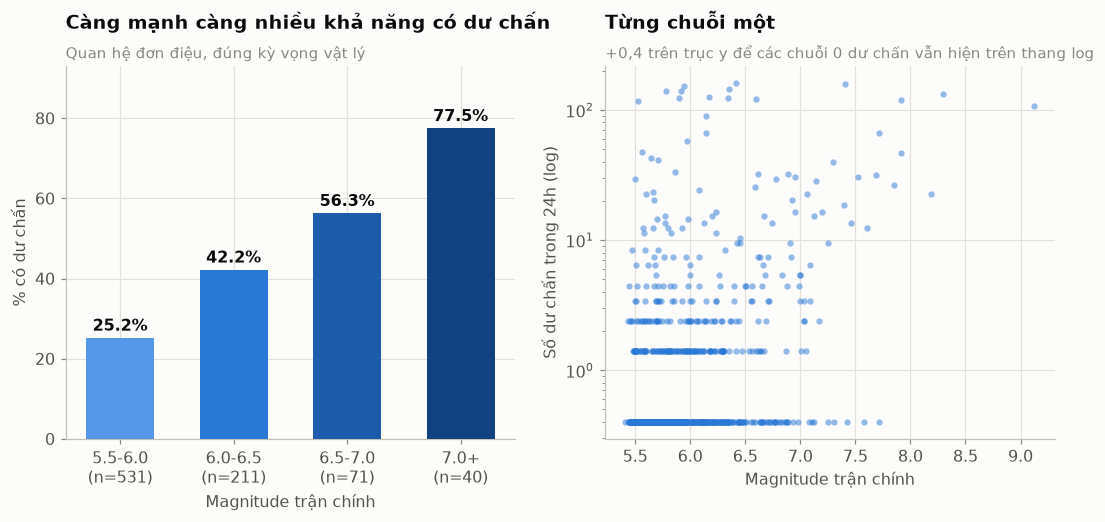

In [16]:
# Hinh 4: magnitude vs so du chan
ms["mag_bin"] = pd.cut(ms["mag"], [5.5, 6.0, 6.5, 7.0, 9.5],
                       labels=["5.5-6.0","6.0-6.5","6.5-7.0","7.0+"], right=False)
g2 = ms.groupby("mag_bin", observed=True).agg(
    n=("any_after","size"), pct=("any_after","mean"), tb=("n_after24h","mean"))
g2["pct"] = (g2["pct"]*100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.4))
ax = axes[0]
tick2 = [f"{l}\n(n={nn})" for l, nn in zip(g2.index.astype(str), g2["n"])]
bars = ax.bar(tick2, g2["pct"], color=SEQ5[1:5], width=0.6, zorder=3)
for bar, v in zip(bars, g2["pct"]):
    ax.text(bar.get_x()+bar.get_width()/2, v+1.8, f"{v:.1f}%", ha="center",
            fontsize=10.5, color=PAL["ink"], fontweight="semibold")
finish(ax, "Càng mạnh càng nhiều khả năng có dư chấn", "Quan hệ đơn điệu, đúng kỳ vọng vật lý",
       "Magnitude trận chính", "% có dư chấn")
ax.set_ylim(0, max(g2["pct"])*1.2)

ax = axes[1]
jit = np.random.default_rng(0).normal(0, 0.035, len(ms))
ax.scatter(ms["mag"]+jit, ms["n_after24h"]+0.4, s=17, alpha=0.5,
           color=PAL["s1"], linewidths=0, zorder=3)
ax.set_yscale("log")
finish(ax, "Từng chuỗi một", "+0,4 trên trục y để các chuỗi 0 dư chấn vẫn hiện trên thang log",
       "Magnitude trận chính", "Số dư chấn trong 24h (log)")
save(fig, "fig_rq1_magnitude_vs_aftershocks.png"); plt.show()

## Test case của Notebook_A (chạy trước khi bàn giao)

Sáu phép kiểm. Nếu có `AssertionError` thì **không được bàn giao** cho Notebook_B.

In [17]:
# Test case Notebook_A
def t(name, cond, detail=""):
    assert cond, f"FAIL: {name} {detail}"
    print(f"  PASS  {name}")

print("Test case Notebook_A")
t("1. khong co id trung trong catalog", cat["id"].is_unique)
t("2. nhan khong nam trong dac trung",
  "n_after24h" not in ("mag","depth","latitude","longitude"))
t("3. nhan co bien thien (khong suy bien)",
  0.05 < ms["any_after"].mean() < 0.95, f"ty le duong = {ms['any_after'].mean():.3f}")
t("4. so group doc lap du lon", len(ms) >= 300, f"chi co {len(ms)} chuoi")
t("5. ghep nguon 2 dat tren 80%", len(link)/len(nc) >= 0.80,
  f"chi ghep {len(link)/len(nc)*100:.1f}%")
t("6. moi dac trung deu biet duoc o thoi diem t",
  all(c in cat.columns for c in ("mag","depth","latitude","longitude")))

# kiem tra khong ro ri: nhan phai doc lap voi chinh no o qua khu
corr = ms[["mag","depth","n_after24h"]].corr(method="spearman")["n_after24h"]
print("\nTuong quan Spearman voi nhan (khong duoc co cot nao ~ 1.0):")
print(corr.round(3).to_string())
t("7. khong co dac trung nao trung voi nhan", (corr.drop("n_after24h").abs() < 0.95).all())

Test case Notebook_A
  PASS  1. khong co id trung trong catalog
  PASS  2. nhan khong nam trong dac trung
  PASS  3. nhan co bien thien (khong suy bien)
  PASS  4. so group doc lap du lon
  PASS  5. ghep nguon 2 dat tren 80%
  PASS  6. moi dac trung deu biet duoc o thoi diem t

Tuong quan Spearman voi nhan (khong duoc co cot nao ~ 1.0):
mag           0.276
depth        -0.492
n_after24h    1.000
  PASS  7. khong co dac trung nao trung voi nhan


In [18]:
# Ban giao cho Notebook_B
OUT_COLS = ["id","time","year","latitude","longitude","depth","mag","magType","place",
            "depth_bin","n_after24h","any_after"]
ms[OUT_COLS].to_parquet(PROC / "mainshocks.parquet", index=False)
cat[["id","time","latitude","longitude","depth","mag","is_aftershock"]].to_parquet(
    PROC / "catalog_declustered.parquet", index=False)
link.to_parquet(PROC / "source_link.parquet", index=False)

def sha(p):
    return hashlib.sha256(open(p, "rb").read()).hexdigest()[:16]

manifest = {
    "de_tai": "Du bao du chan ngan han vung Nhat-Kuril",
    "nguon_1": {"co_quan":"USGS","bo_du_lieu":"ANSS ComCat (FDSN Event Web Service)",
                "so_su_kien_tho": int(len(usgs)), "so_su_kien_sach": int(len(h))},
    "nguon_2": {"co_quan":"NOAA/NCEI",
                "significant_earthquakes": int(len(ncei_eq)),
                "tsunami_events": int(len(ncei_tsu)),
                "tsunami_runups": int(len(ncei_run)),
                "ty_le_ghep_voi_usgs": round(len(link)/len(nc), 4)},
    "hop_bao": {"lat":[24,46], "lon":[122,150], "ten_vung":"Nhat-Kuril"},
    "Mc": float(Mc), "he_so_b": round(float(-b_gr), 3),
    "declustering": "Gardner-Knopoff 1974",
    "pct_la_du_chan": round(float(cat["is_aftershock"].mean()), 4),
    "nguong_tran_chinh": float(MS_MIN),
    "cua_so_nhan": {"gio": WIN_H, "km": WIN_KM, "mag_toi_thieu": float(Mc)},
    "so_chuoi": int(len(ms)),
    "ty_le_duong": round(float(ms["any_after"].mean()), 4),
    "moc_naive_do_chinh_xac": round(float(max(ms["any_after"].mean(), 1-ms["any_after"].mean())), 4),
    "cot_ban_giao": OUT_COLS,
    "cot_da_loai": audit.loc[audit["quyet_dinh"]=="LOAI","cot"].tolist(),
    "sha256_mainshocks": sha(PROC / "mainshocks.parquet"),
}
with open(PROC / "manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)
print(json.dumps(manifest, ensure_ascii=False, indent=2))
print("\nDA BAN GIAO:", PROC / "mainshocks.parquet", "va", PROC / "manifest.json")

{
  "de_tai": "Du bao du chan ngan han vung Nhat-Kuril",
  "nguon_1": {
    "co_quan": "USGS",
    "bo_du_lieu": "ANSS ComCat (FDSN Event Web Service)",
    "so_su_kien_tho": 40931,
    "so_su_kien_sach": 40924
  },
  "nguon_2": {
    "co_quan": "NOAA/NCEI",
    "significant_earthquakes": 429,
    "tsunami_events": 385,
    "tsunami_runups": 12939,
    "ty_le_ghep_voi_usgs": 0.973
  },
  "hop_bao": {
    "lat": [
      24,
      46
    ],
    "lon": [
      122,
      150
    ],
    "ten_vung": "Nhat-Kuril"
  },
  "Mc": 4.6,
  "he_so_b": 1.018,
  "declustering": "Gardner-Knopoff 1974",
  "pct_la_du_chan": 0.6233,
  "nguong_tran_chinh": 5.5,
  "cua_so_nhan": {
    "gio": 24,
    "km": 100,
    "mag_toi_thieu": 4.6
  },
  "so_chuoi": 853,
  "ty_le_duong": 0.3447,
  "moc_naive_do_chinh_xac": 0.6553,
  "cot_ban_giao": [
    "id",
    "time",
    "year",
    "latitude",
    "longitude",
    "depth",
    "mag",
    "magType",
    "place",
    "depth_bin",
    "n_after24h",
    "any_after"
  

## Lỗi thường gặp và cách xử lý (đọc khi thấy chữ đỏ)

| Chữ đỏ | Nguyên nhân | Cách sửa |
|---|---|---|
| `AssertionError: Thieu file trong data/raw_japan` | chưa tải dữ liệu | chạy `python scripts/fetch_japan_quake_data.py` |
| `ValueError: time data ... doesn't match format` | pandas đoán sai định dạng ISO | đã xử lý bằng `format="ISO8601"`; nếu vẫn lỗi thì thêm `errors="coerce"` rồi `dropna` |
| `ModuleNotFoundError: duckdb` | thiếu thư viện | `pip install duckdb pyarrow` |
| `Binder Error: ... WINDOW` | DuckDB quá cũ, chưa hỗ trợ `WINDOW ... AS` | `pip install -U duckdb` (cần ≥ 0.9) |
| Q3 trả về `so_tran_24h_truoc` toàn 0 | dùng `ROWS` thay vì `RANGE` | phải là `RANGE BETWEEN INTERVAL '24' HOURS PRECEDING` |
| `AssertionError: so group doc lap du lon` | ngưỡng `MS_MIN` đặt quá cao | hạ `MS_MIN` xuống 5.0 và ghi rõ trong report |
| Hình ra chữ ô vuông ở nhãn tiếng Việt | font thiếu glyph | `plt.rcParams["font.family"]="DejaVu Sans"` |

## Checklist trước khi báo cáo (đánh dấu [x] khi có file bằng chứng)

- [ ] `data/processed/mainshocks.parquet` và `manifest.json` đã tạo, Notebook_B nạp được
- [ ] `sql/queries.sql` có đủ 9 truy vấn và **chạy lại được** trong DuckDB
- [ ] `report/table_col_audit.csv` — nêu rõ cột nào loại và **vì sao**
- [ ] `report/table_cleaning_log.csv` — số dòng mất ở từng bước
- [ ] `report/table_source_link.csv` — tỉ lệ ghép hai nguồn
- [ ] `report/table_rq1_tests.csv` — chi-square, Kruskal–Wallis, Spearman kèm p-value
- [ ] `report/table_rq1_productivity.csv` — bảng năng suất theo độ sâu
- [ ] 5 hình `fig_rq1_*.png` đọc được, chữ không bị tràn, nhãn tiếng Việt hiện đúng
- [ ] Cả 7 test case PASS
- [ ] `docs/AI_Audit_Log_A.md` có dòng cho mọi prompt đã làm thay đổi bài
- [ ] Trong report **đã ghi** ba giới hạn: (1) vùng gồm cả Kuril của Nga, (2) USGS không phải cơ quan chính của Nhật nên Mc cao, (3) năm 2011 lấn át

## Mẫu báo cáo tiến độ (slot 3 thứ Ba và thứ Sáu, 7:00 đến 9:15)

**Sinh viên A — Notebook_A — tuần …**

1. **Đã xong:** nạp 2 nguồn (USGS … trận / NOAA/NCEI … trận), làm sạch còn … dòng, Mc = …, decluster ra … chuỗi độc lập, 9 truy vấn SQL, 5 hình RQ1.
2. **Số chính:** tỉ lệ trận chính có dư chấn trong 24h = … %; nông (<70 km) … % so với sâu (≥70 km) … %, chi-square p = …
3. **Ghép nguồn 2:** … / … = … %, lệch thời gian trung vị … giây.
4. **Vướng:** …
5. **Tuần tới:** bàn giao `mainshocks.parquet` cho B; B chạy Bước 4 và 6a.
6. **Giới hạn đã ghi vào report:** …